# 클러스터링에 쓸 데이터만 정제
- 기초수급자 인구밀도
- 인당녹지면적
- 공시지가

In [49]:
import pandas as pd
df = pd.read_csv('data/최종_데이터/최종_분석데이터.csv',encoding='cp949')

df['행정동코드']=df['행정동코드'].astype(object)
df['법정동코드']=df['법정동코드'].astype(object)
df['grid']=df['grid'].astype(object)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30317 entries, 0 to 30316
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   grid        30317 non-null  object 
 1   시도          30317 non-null  object 
 2   시군구         30317 non-null  object 
 3   행정동         30317 non-null  object 
 4   행정동코드       30317 non-null  object 
 5   법정동코드       30317 non-null  object 
 6   법정동         30317 non-null  object 
 7   대중교통        30317 non-null  float64
 8   도시재생사업수     30317 non-null  int64  
 9   기초수급자_인구밀도  30317 non-null  float64
 10  저소득층_비율     30317 non-null  float64
 11  총생활인구       30317 non-null  float64
 12  초미세먼지       30317 non-null  int64  
 13  미세먼지        30317 non-null  int64  
 14  인당녹지면적      30317 non-null  float64
 15  토지공시지가평균    30317 non-null  float64
 16  임야공시지가평균    30317 non-null  float64
 17  총공시지가평균     30317 non-null  float64
 18  토지유형        30317 non-null  object 
 19  평균기온(°C)    30317 non-nul

In [51]:
df_행정동 = df.groupby(['시군구','행정동']).mean().drop('대중교통',axis=1).reset_index()
df_행정동.to_csv('data/동별데이터.csv',encoding='cp949',index=False)

In [33]:
df_시군구 = df.groupby('시군구').agg({'기초수급자_인구밀도':'mean','저소득층_비율':'sum','총생활인구':'sum','초미세먼지':'mean','미세먼지':'mean','인당녹지면적':'sum','총공시지가평균':'mean','평균기온(°C)':'mean'}).reset_index()

## 도시재생사업수

In [37]:
cnt = pd.read_csv('data/도시재생동별갯수.csv',encoding='cp949')
cat = pd.read_excel('data/한국행정구역분류_정제.xlsx',sheet_name='법정동')

In [42]:
df_도시재생사업 = pd.merge(cat,cnt).groupby('시군구').agg({'갯수':'sum'}).reset_index()

In [45]:
final_시군구 = pd.merge(df_시군구, df_도시재생사업).rename(columns={'갯수':'도시재생사업수'})

In [46]:
final_시군구.to_csv('data/구별데이터.csv',encoding='cp949',index=False)

In [52]:
df_행정동.도시재생사업수.sum()

143.0

In [53]:
final_시군구.도시재생사업수.sum()

92

In [27]:
import pandas as pd

df = pd.read_csv('data/구별데이터.csv',encoding='cp949').drop('저소득층_비율',axis=1)
df

,시군구,기초수급자_인구밀도,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수
0,강남구,562.48,201448520.05,20.00,37.00,18673.63,12253031.75,-0.05,0
1,강동구,929.36,94988232.33,21.00,39.00,10745.79,3851910.89,-0.45,4
2,강북구,1608.31,39956335.64,19.00,39.00,3741.51,2848680.48,-0.25,6
3,강서구,847.76,168934985.48,22.00,41.00,43885.47,2775143.97,-0.75,1
4,관악구,1335.63,38076142.70,19.00,36.00,1661.40,4194807.33,-1.80,2
5,광진구,1007.31,50548732.38,20.00,37.00,1963.89,4741415.00,-0.15,1
6,구로구,978.23,72564078.18,20.00,40.00,3764.59,3019997.00,-0.15,4
7,금천구,921.37,40516352.87,22.00,38.00,312.06,3153749.59,0.30,3
8,노원구,1304.93,69255024.34,21.00,38.00,4924.13,2662753.61,-2.35,2
9,도봉구,1309.44,30595816.41,19.00,37.00,5500.79,2565664.80,-1.35,4


In [28]:
data = pd.read_csv('data/저소득층_비율.csv',encoding='cp949')
data = data.groupby('시군구').agg({'저소득층_비율':'sum'}).reset_index()

In [30]:
final_df = pd.merge(df,data, on='시군구')

In [34]:
final_df = final_df[['시군구','기초수급자_인구밀도','저소득층_비율','총생활인구','총공시지가평균','도시재생사업수','인당녹지면적','초미세먼지','미세먼지','평균기온(°C)']]

In [36]:
final_df = final_df.rename(columns={'저소득층_비율':'저소득층_분포비율'})

In [38]:
import dataframe_image as dfi

dfi.export(final_df, './image/df_구별데이터.png', max_cols = -1, max_rows = -1)

In [39]:
final_df.to_csv('data/구별데이터.csv',encoding='cp949',index=False)

In [41]:
final_df.corr()

,기초수급자_인구밀도,저소득층_분포비율,총생활인구,총공시지가평균,도시재생사업수,인당녹지면적,초미세먼지,미세먼지,평균기온(°C)
기초수급자_인구밀도,1.00,0.23,-0.37,-0.71,0.23,-0.42,-0.11,-0.11,-0.16
저소득층_분포비율,0.23,1.00,0.63,-0.17,-0.55,0.22,-0.08,-0.14,0.00
총생활인구,-0.37,0.63,1.00,0.37,-0.58,0.64,0.18,0.06,0.21
총공시지가평균,-0.71,-0.17,0.37,1.00,-0.33,0.35,-0.04,0.07,0.08
도시재생사업수,0.23,-0.55,-0.58,-0.33,1.00,-0.42,-0.10,0.02,-0.08
인당녹지면적,-0.42,0.22,0.64,0.35,-0.42,1.00,0.30,0.44,-0.11
초미세먼지,-0.11,-0.08,0.18,-0.04,-0.10,0.30,1.00,0.45,-0.27
미세먼지,-0.11,-0.14,0.06,0.07,0.02,0.44,0.45,1.00,-0.08
평균기온(°C),-0.16,0.00,0.21,0.08,-0.08,-0.11,-0.27,-0.08,1.00


# 전체데이터

In [7]:
import pandas as pd
df = pd.read_csv('data/구별데이터.csv',encoding='cp949')
data = pd.read_csv('data/정제데이터/구별_공원녹지면적.csv',encoding='cp949').rename(columns={'결정면적':'공원녹지면적'})

In [10]:
final = pd.merge(data,df,how='outer')

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import Markdown as md
except ImportError:
    pass

# 한글폰트
import os
from matplotlib import font_manager, rc
path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname=path, size=50).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False 


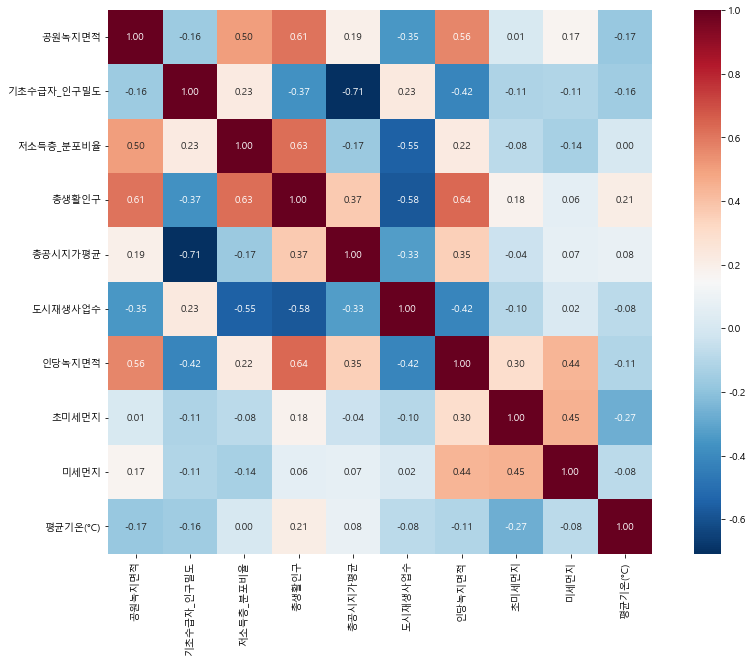

In [14]:
fig=plt.gcf()
fig.set_size_inches(15,10)
hm=sns.heatmap(final.corr(), cmap='RdBu_r', square=True, cbar=True, annot=True, fmt=".2f")

In [62]:
fig.savefig('image/구별데이터_corr_heatmap.png')